# Chapter 16: 프롬프트 엔지니어링과 LLM 모델 비교

## 학습 목표

이 장에서는 다음을 학습합니다:

1. **CAIS 프롬프트 분석**: 인과추론 라이브러리의 프롬프트 템플릿 이해
2. **프롬프트 전략**: Zero-shot vs Few-shot vs Chain-of-Thought (CoT) 비교
3. **구조화된 출력**: Pydantic 모델을 이용한 프롬프트 개선
4. **모델 비교**: gpt-4o vs gpt-4o-mini의 성능/비용 트레이드오프
5. **프롬프트 최적화**: 시스템 메시지 설계 원칙
6. **비용-성능 분석**: 실전 의사결정 가이드
7. **템플릿 설계**: 인과추론 프롬프트 모범 사례

In [1]:
# 필요한 라이브러리 임포트
import os
import json
import time
from datetime import datetime
from typing import Optional, List, Dict
from dataclasses import dataclass
from enum import Enum

from openai import OpenAI
from pydantic import BaseModel, Field
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

# OpenAI 클라이언트 초기화
api_key = os.getenv('OPENAI_API_KEY')
if not api_key:
    raise ValueError("OPENAI_API_KEY 환경변수가 설정되지 않았습니다.")

client = OpenAI(api_key=api_key)

# 시각화 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("환경 초기화 완료!")
print(f"OpenAI API 연결 상태: {'OK' if api_key else 'FAILED'}")

환경 초기화 완료!
OpenAI API 연결 상태: OK


## 1. CAIS 프롬프트 분석

Causal Agent는 인과추론 작업을 자동화하기 위해 설계된 프롬프트 템플릿을 사용합니다.

### 핵심 프롬프트들:

- **RCT_IDENTIFICATION_PROMPT**: 데이터셋이 RCT(무작위대조시험)인지 판정
- **OUTCOME_VAR_IDENTIFICATION_PROMPT**: 결과 변수 자동 식별
- **TREATMENT_VAR_IDENTIFICATION_PROMPT**: 처치 변수 자동 식별
- **CONFOUNDER_IDENTIFICATION_PROMPT**: 교란 변수 식별

이들 프롬프트는 데이터 설명으로부터 인과추론에 필요한 주요 변수들을 추출합니다.

In [2]:
# Caual AI Agent 프롬프트 템플릿 분석

CAIS_PROMPTS = {
    "RCT_IDENTIFICATION": """주어진 데이터셋 설명을 분석하여 다음을 판정하세요:
        1. 이 데이터는 RCT(무작위대조시험)에서 나온 것인가?
        2. 무작위화 증거는 무엇인가?
        3. 신뢰도 수준은 어느 정도인가?
        
        데이터셋: {description}
        
        결과는 JSON 형식으로 제공하세요:
        {"is_rct": bool, "evidence": str, "confidence": float}""",
        
            "OUTCOME_VAR_IDENTIFICATION": """사용자 질문과 데이터셋 설명으로부터 결과(아웃컴) 변수를 식별하세요.
        사용자 질문: {query}
        데이터셋: {description}
        
        다음을 포함한 JSON을 반환하세요:
        {"outcome_variable": str, "type": str, "description": str}""",
        
            "TREATMENT_VAR_IDENTIFICATION": """사용자 질문과 데이터셋 설명으로부터 처치 변수를 식별하세요.
        사용자 질문: {query}
        데이터셋: {description}
        
        다음을 포함한 JSON을 반환하세요:
        {"treatment_variable": str, "type": str, "values": list}""",
        
            "CONFOUNDER_IDENTIFICATION": """결과 변수와 처치 변수가 주어졌을 때, 교란 변수(confounders)를 식별하세요.
        결과 변수: {outcome_var}
        처치 변수: {treatment_var}
        데이터셋: {description}
        
        다음을 포함한 JSON을 반환하세요:
        {"confounders": list, "justification": str}"""
        }

print("핵심 프롬프트 템플릿:")
print("=" * 60)
for name, template in CAIS_PROMPTS.items():
    print(f"\n[{name}]")
    print(f"변수 수: {len([m for m in template.split('{') if m.startswith('')])}")
    print(f"길이: {len(template)} 문자")
    print("-" * 40)

핵심 프롬프트 템플릿:

[RCT_IDENTIFICATION]
변수 수: 3
길이: 245 문자
----------------------------------------

[OUTCOME_VAR_IDENTIFICATION]
변수 수: 4
길이: 187 문자
----------------------------------------

[TREATMENT_VAR_IDENTIFICATION]
변수 수: 4
길이: 180 문자
----------------------------------------

[CONFOUNDER_IDENTIFICATION]
변수 수: 5
길이: 218 문자
----------------------------------------


## 2. Zero-shot vs Few-shot vs Chain-of-Thought (CoT)

프롬프트 전략에 따라 LLM의 성능이 크게 달라집니다.

### 전략 비교:

- **Zero-shot**: 예시 없이 바로 질문 → 빠르지만 정확도 낮음
- **Few-shot**: 1-3개 예시 제공 → 정확도 향상, 비용 증가
- **Chain-of-Thought (CoT)**: 단계별 추론 → 가장 정확하지만 비용 높음

In [4]:
# 프롬프트 전략 비교 클래스
class PromptStrategy(str, Enum):
    """프롬프트 전략 열거형"""
    ZERO_SHOT = "zero-shot"
    FEW_SHOT = "few-shot"
    COT = "chain-of-thought"

def create_variable_identification_prompt(strategy: PromptStrategy, query: str, description: str) -> str:
    """전략에 따른 프롬프트 생성"""
    
    if strategy == PromptStrategy.ZERO_SHOT:
        return f"""데이터셋 설명에서 결과 변수를 식별하세요.
데이터셋: {description}
질문: {query}
결과 변수명을 말하세요."""
    
    elif strategy == PromptStrategy.FEW_SHOT:
        return f"""다음 예시를 참고하여 결과 변수를 식별하세요.

예시 1:
질문: 처리가 판매량에 미치는 영향?
데이터: 고객ID, 처리여부, 판매량, 구매일시
결과 변수: 판매량

예시 2:
질문: 교육이 급여에 미치는 영향?
데이터: 사원ID, 교육여부, 급여, 경력
결과 변수: 급여

이제 다음 질문에 답하세요:
데이터셋: {description}
질문: {query}
결과 변수명을 말하세요."""
    
    elif strategy == PromptStrategy.COT:
        return f"""다음 단계별로 결과 변수를 식별하세요:

1단계: 사용자의 핵심 질문을 파악하세요.
2단계: 데이터셋의 변수들을 나열하세요.
3단계: 각 변수가 질문과의 관계를 분석하세요.
4단계: 결과 변수 후보를 식별하세요.
5단계: 최종 결과 변수를 선택하고 이유를 설명하세요.

데이터셋: {description}
질문: {query}

위 단계를 따라 결과 변수를 식별하고 추론 과정을 설명하세요."""
    
    return ""

# 각 전략별 프롬프트 예시 표시
print("프롬프트 전략별 예시:")
print("=" * 70)

test_query = "약물 치료가 혈압에 미치는 영향?"
test_desc = "환자ID, 치료약물, 혈압, 나이, 성별, 병력"

for strategy in PromptStrategy:
    prompt = create_variable_identification_prompt(strategy, test_query, test_desc)
    print(f"\n[{strategy.value.upper()}]")
    print(f"길이: {len(prompt)} 문자")
    print("프롬프트 미리보기:")
    print(prompt[:200] + "...")
    print("-" * 70)

프롬프트 전략별 예시:

[ZERO-SHOT]
길이: 93 문자
프롬프트 미리보기:
데이터셋 설명에서 결과 변수를 식별하세요.
데이터셋: 환자ID, 치료약물, 혈압, 나이, 성별, 병력
질문: 약물 치료가 혈압에 미치는 영향?
결과 변수명을 말하세요....
----------------------------------------------------------------------

[FEW-SHOT]
길이: 239 문자
프롬프트 미리보기:
다음 예시를 참고하여 결과 변수를 식별하세요.

예시 1:
질문: 처리가 판매량에 미치는 영향?
데이터: 고객ID, 처리여부, 판매량, 구매일시
결과 변수: 판매량

예시 2:
질문: 교육이 급여에 미치는 영향?
데이터: 사원ID, 교육여부, 급여, 경력
결과 변수: 급여

이제 다음 질문에 답하세요:
데이터셋: 환자ID, 치료약물, 혈압, 나이, 성별, ...
----------------------------------------------------------------------

[CHAIN-OF-THOUGHT]
길이: 242 문자
프롬프트 미리보기:
다음 단계별로 결과 변수를 식별하세요:

1단계: 사용자의 핵심 질문을 파악하세요.
2단계: 데이터셋의 변수들을 나열하세요.
3단계: 각 변수가 질문과의 관계를 분석하세요.
4단계: 결과 변수 후보를 식별하세요.
5단계: 최종 결과 변수를 선택하고 이유를 설명하세요.

데이터셋: 환자ID, 치료약물, 혈압, 나이, 성별, 병력
질문: 약물 치료가 혈압에 미...
----------------------------------------------------------------------


## 3. 구조화된 출력과 프롬프트 최적화

Pydantic을 이용한 구조화된 출력은 LLM의 응답을 일관되게 파싱할 수 있게 합니다.

In [5]:
# Pydantic 모델 정의
class VariableIdentification(BaseModel):
    """변수 식별 결과 모델"""
    outcome_variable: str = Field(..., description="결과 변수명")
    variable_type: str = Field(..., description="변수 타입 (연속, 범주)")
    evidence: str = Field(..., description="식별 근거")
    confidence: float = Field(..., ge=0, le=1, description="신뢰도 (0-1)")

class TreatmentIdentification(BaseModel):
    """처치 변수 식별 결과 모델"""
    treatment_variable: str = Field(..., description="처치 변수명")
    treatment_type: str = Field(..., description="처치 타입 (이진, 다중수준)")
    levels: List[str] = Field(..., description="처치 수준")
    confidence: float = Field(..., ge=0, le=1, description="신뢰도")

class ConfounderIdentification(BaseModel):
    """교란 변수 식별 결과 모델"""
    confounders: List[str] = Field(..., description="교란 변수 리스트")
    justification: str = Field(..., description="식별 근거")
    causal_paths: Dict[str, str] = Field(..., description="각 교란변수의 인과경로")

print("Pydantic 모델 정의 완료!")
print(f"\n정의된 모델:")
print(f"- VariableIdentification: 결과 변수 식별")
print(f"- TreatmentIdentification: 처치 변수 식별")
print(f"- ConfounderIdentification: 교란 변수 식별")

Pydantic 모델 정의 완료!

정의된 모델:
- VariableIdentification: 결과 변수 식별
- TreatmentIdentification: 처치 변수 식별
- ConfounderIdentification: 교란 변수 식별


In [6]:
# 구조화된 프롬프트 생성 함수
def create_structured_prompt(
    task: str,
    system_message: str,
    user_input: str,
    output_format: str
) -> Dict[str, str]:
    """구조화된 프롬프트 생성"""
    
    return {
        "system": system_message,
        "user": user_input,
        "format": output_format
    }

# 예시: 기본 시스템 메시지 vs 최적화된 시스템 메시지
system_basic = "너는 데이터 분석 도우미다."

system_optimized = """너는 인과추론 전문가이다. 다음 원칙을 따르라:
1. 데이터 설명을 신중히 분석하라.
2. 명시적이고 암시적인 변수들을 모두 고려하라.
3. 도메인 지식을 활용하여 인과관계를 파악하라.
4. 불확실한 경우 신뢰도를 낮게 표시하라.
5. 항상 근거를 제시하라."""

print("시스템 메시지 비교:")
print("=" * 70)
print("\n[기본]")
print(f"길이: {len(system_basic)}")
print(system_basic)

print("\n[최적화]")
print(f"길이: {len(system_optimized)}")
print(system_optimized)

print("\n개선 사항:")
print("- 역할 정의 강화 (도우미 → 전문가)")
print("- 명확한 원칙 제시")
print("- 단계별 지침")
print("- 신뢰도 표기 요청")
print("- 근거 요구")

시스템 메시지 비교:

[기본]
길이: 15
너는 데이터 분석 도우미다.

[최적화]
길이: 144
너는 인과추론 전문가이다. 다음 원칙을 따르라:
1. 데이터 설명을 신중히 분석하라.
2. 명시적이고 암시적인 변수들을 모두 고려하라.
3. 도메인 지식을 활용하여 인과관계를 파악하라.
4. 불확실한 경우 신뢰도를 낮게 표시하라.
5. 항상 근거를 제시하라.

개선 사항:
- 역할 정의 강화 (도우미 → 전문가)
- 명확한 원칙 제시
- 단계별 지침
- 신뢰도 표기 요청
- 근거 요구


## 4. gpt-4o vs gpt-4o-mini 성능 비교

모델 선택은 비용, 속도, 정확도 간의 트레이드오프입니다.

### 모델 특성:

| 특성 | gpt-4o | gpt-4o-mini |
|------|--------|-------------|
| 입력 토큰 비용 | $5/M | $0.15/M |
| 출력 토큰 비용 | $15/M | $0.60/M |
| 추론 정확도 | 높음 | 중간 |
| 응답 속도 | 보통 | 빠름 |
| 맥락 창 | 128K | 128K |

In [8]:
# 모델 비교 데이터
@dataclass
class ModelComparison:
    """모델 성능 비교 데이터"""
    model_name: str
    input_cost_per_m: float  # $ per million tokens
    output_cost_per_m: float  # $ per million tokens
    avg_latency_ms: float  # milliseconds
    avg_accuracy: float  # 0-1

models = {
    "gpt-5.3": ModelComparison(
        model_name="gpt-5.3",
        input_cost_per_m=5.0,
        output_cost_per_m=15.0,
        avg_latency_ms=800,
        avg_accuracy=0.92
    ),
    "gpt-5.3-mini": ModelComparison(
        model_name="gpt-5.3-mini",
        input_cost_per_m=0.15,
        output_cost_per_m=0.60,
        avg_latency_ms=300,
        avg_accuracy=0.78
    )
}

print("모델 성능 비교:")
print("=" * 80)
for name, comp in models.items():
    print(f"\n{name}:")
    print(f"  입력 비용: ${comp.input_cost_per_m}/M 토큰")
    print(f"  출력 비용: ${comp.output_cost_per_m}/M 토큰")
    print(f"  평균 지연: {comp.avg_latency_ms}ms")
    print(f"  정확도: {comp.avg_accuracy:.1%}")

# 비용 계산 함수
def calculate_cost(model: str, input_tokens: int, output_tokens: int) -> float:
    """API 호출 비용 계산"""
    m = models[model]
    input_cost = (input_tokens / 1_000_000) * m.input_cost_per_m
    output_cost = (output_tokens / 1_000_000) * m.output_cost_per_m
    return input_cost + output_cost

print("\n" + "=" * 80)
print("\n비용 계산 예시 (입력: 500 토큰, 출력: 200 토큰):")
for model_name in models.keys():
    cost = calculate_cost(model_name, 500, 200)
    print(f"  {model_name}: ${cost:.4f}")

모델 성능 비교:

gpt-5.3:
  입력 비용: $5.0/M 토큰
  출력 비용: $15.0/M 토큰
  평균 지연: 800ms
  정확도: 92.0%

gpt-5.3-mini:
  입력 비용: $0.15/M 토큰
  출력 비용: $0.6/M 토큰
  평균 지연: 300ms
  정확도: 78.0%


비용 계산 예시 (입력: 500 토큰, 출력: 200 토큰):
  gpt-5.3: $0.0055
  gpt-5.3-mini: $0.0002


In [9]:
# 모델 비교 시뮬레이션
class ModelBenchmark:
    """모델 벤치마크 실행기"""
    
    def __init__(self, client):
        self.client = client
        self.results = []
    
    def test_prompt(self, model: str, prompt: str, max_tokens: int = 100) -> Dict:
        """프롬프트를 모델로 테스트"""
        try:
            start_time = time.time()
            
            response = self.client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "너는 데이터 분석 전문가다."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=max_tokens,
                temperature=0.5
            )
            
            elapsed = time.time() - start_time
            
            return {
                "model": model,
                "success": True,
                "response": response.choices[0].message.content,
                "input_tokens": response.usage.prompt_tokens,
                "output_tokens": response.usage.completion_tokens,
                "latency_ms": elapsed * 1000,
                "cost": calculate_cost(model, response.usage.prompt_tokens, response.usage.completion_tokens)
            }
        except Exception as e:
            return {
                "model": model,
                "success": False,
                "error": str(e)
            }

print("ModelBenchmark 클래스 정의 완료!")
print("\n벤치마크 준비 상태: OK")
print("\n참고: 실제 API 호출은 OPENAI_API_KEY가 필요합니다.")

ModelBenchmark 클래스 정의 완료!

벤치마크 준비 상태: OK

참고: 실제 API 호출은 OPENAI_API_KEY가 필요합니다.


## 5. 프롬프트 최적화 전략

좋은 프롬프트는 다음 요소들을 포함합니다:

1. **역할 정의**: "너는 인과추론 전문가다"
2. **맥락 제공**: 데이터셋 설명, 변수 정의
3. **명확한 지침**: 단계별 지시사항
4. **출력 형식 지정**: JSON, 구조화된 텍스트
5. **제약 조건**: 신뢰도, 근거 요구

In [10]:
# 프롬프트 최적화 전후 비교
class PromptOptimization:
    """프롬프트 최적화 분석"""
    
    @staticmethod
    def basic_prompt() -> str:
        """최적화되지 않은 프롬프트"""
        return """데이터에서 중요한 변수를 찾으세요.
데이터: 고객ID, 마케팅, 판매량, 지역"""
    
    @staticmethod
    def optimized_prompt() -> str:
        """최적화된 프롬프트"""
        return """너는 인과추론 전문가이다.

작업: 마케팅 캠페인이 판매량에 미치는 영향을 분석하기 위한 변수들을 식별하라.

데이터셋 설명:
- 고객ID: 각 고객 고유 식별자
- 마케팅: 마케팅 캠페인 노출 여부 (이진변수)
- 판매량: 고객당 월간 판매량 (연속변수)
- 지역: 고객 거주 지역 (범주변수)

분석 단계:
1. 결과 변수 (Outcome)를 식별하고 이유를 설명하라
2. 처치 변수 (Treatment)를 식별하고 이유를 설명하라
3. 교란 변수 (Confounder)를 식별하고 인과경로를 설명하라

출력 형식:
{
  "outcome": {"name": str, "type": str, "reason": str},
  "treatment": {"name": str, "type": str, "reason": str},
  "confounders": [{"name": str, "paths": list}]
}"""
    
    @staticmethod
    def analyze_prompt(prompt: str) -> Dict:
        """프롬프트 품질 분석"""
        analysis = {
            "길이": len(prompt),
            "줄수": prompt.count('\n'),
            "역할정의": "너는" in prompt,
            "단계지침": "단계" in prompt or "1." in prompt,
            "맥락정보": "설명" in prompt or "데이터셋" in prompt,
            "출력형식": "{" in prompt and "}" in prompt,
            "근거요구": "이유" in prompt or "근거" in prompt
        }
        return analysis

print("프롬프트 최적화 비교:")
print("=" * 70)

basic = PromptOptimization.basic_prompt()
optimized = PromptOptimization.optimized_prompt()

print("\n[최적화 전]")
print(basic)
print(f"\n분석:")
basic_analysis = PromptOptimization.analyze_prompt(basic)
for key, value in basic_analysis.items():
    print(f"  {key}: {value}")

print("\n" + "=" * 70)
print("\n[최적화 후]")
print(optimized)
print(f"\n분석:")
opt_analysis = PromptOptimization.analyze_prompt(optimized)
for key, value in opt_analysis.items():
    print(f"  {key}: {value}")

프롬프트 최적화 비교:

[최적화 전]
데이터에서 중요한 변수를 찾으세요.
데이터: 고객ID, 마케팅, 판매량, 지역

분석:
  길이: 43
  줄수: 1
  역할정의: False
  단계지침: False
  맥락정보: False
  출력형식: False
  근거요구: False


[최적화 후]
너는 인과추론 전문가이다.

작업: 마케팅 캠페인이 판매량에 미치는 영향을 분석하기 위한 변수들을 식별하라.

데이터셋 설명:
- 고객ID: 각 고객 고유 식별자
- 마케팅: 마케팅 캠페인 노출 여부 (이진변수)
- 판매량: 고객당 월간 판매량 (연속변수)
- 지역: 고객 거주 지역 (범주변수)

분석 단계:
1. 결과 변수 (Outcome)를 식별하고 이유를 설명하라
2. 처치 변수 (Treatment)를 식별하고 이유를 설명하라
3. 교란 변수 (Confounder)를 식별하고 인과경로를 설명하라

출력 형식:
{
  "outcome": {"name": str, "type": str, "reason": str},
  "treatment": {"name": str, "type": str, "reason": str},
  "confounders": [{"name": str, "paths": list}]
}

분석:
  길이: 456
  줄수: 20
  역할정의: True
  단계지침: True
  맥락정보: True
  출력형식: True
  근거요구: True


## 6. 비용-성능 트레이드오프

프롬프트 전략과 모델 선택은 비용과 성능 사이의 균형을 요구합니다.

In [11]:
# 비용-성능 분석
def simulate_batch_processing(num_queries: int, strategy: PromptStrategy) -> Dict:
    """배치 처리 비용-성능 시뮬레이션"""
    
    # 전략별 토큰 사용량 예상
    token_estimates = {
        PromptStrategy.ZERO_SHOT: {"input": 300, "output": 100},
        PromptStrategy.FEW_SHOT: {"input": 600, "output": 120},
        PromptStrategy.COT: {"input": 800, "output": 250}
    }
    
    tokens = token_estimates[strategy]
    
    results = {}
    for model_name, _ in models.items():
        total_input = tokens["input"] * num_queries
        total_output = tokens["output"] * num_queries
        total_cost = calculate_cost(model_name, total_input, total_output)
        
        results[model_name] = {
            "total_cost": total_cost,
            "cost_per_query": total_cost / num_queries,
            "total_tokens": total_input + total_output,
            "expected_accuracy": models[model_name].avg_accuracy
        }
    
    return results

print("비용-성능 분석 (1000 쿼리 기준):")
print("=" * 70)

for strategy in PromptStrategy:
    print(f"\n[{strategy.value.upper()}]")
    results = simulate_batch_processing(1000, strategy)
    
    for model_name, metrics in results.items():
        print(f"\n  {model_name}:")
        print(f"    총 비용: ${metrics['total_cost']:.2f}")
        print(f"    쿼리당: ${metrics['cost_per_query']:.4f}")
        print(f"    예상 정확도: {metrics['expected_accuracy']:.1%}")

비용-성능 분석 (1000 쿼리 기준):

[ZERO-SHOT]

  gpt-5.3:
    총 비용: $3.00
    쿼리당: $0.0030
    예상 정확도: 92.0%

  gpt-5.3-mini:
    총 비용: $0.10
    쿼리당: $0.0001
    예상 정확도: 78.0%

[FEW-SHOT]

  gpt-5.3:
    총 비용: $4.80
    쿼리당: $0.0048
    예상 정확도: 92.0%

  gpt-5.3-mini:
    총 비용: $0.16
    쿼리당: $0.0002
    예상 정확도: 78.0%

[CHAIN-OF-THOUGHT]

  gpt-5.3:
    총 비용: $7.75
    쿼리당: $0.0077
    예상 정확도: 92.0%

  gpt-5.3-mini:
    총 비용: $0.27
    쿼리당: $0.0003
    예상 정확도: 78.0%


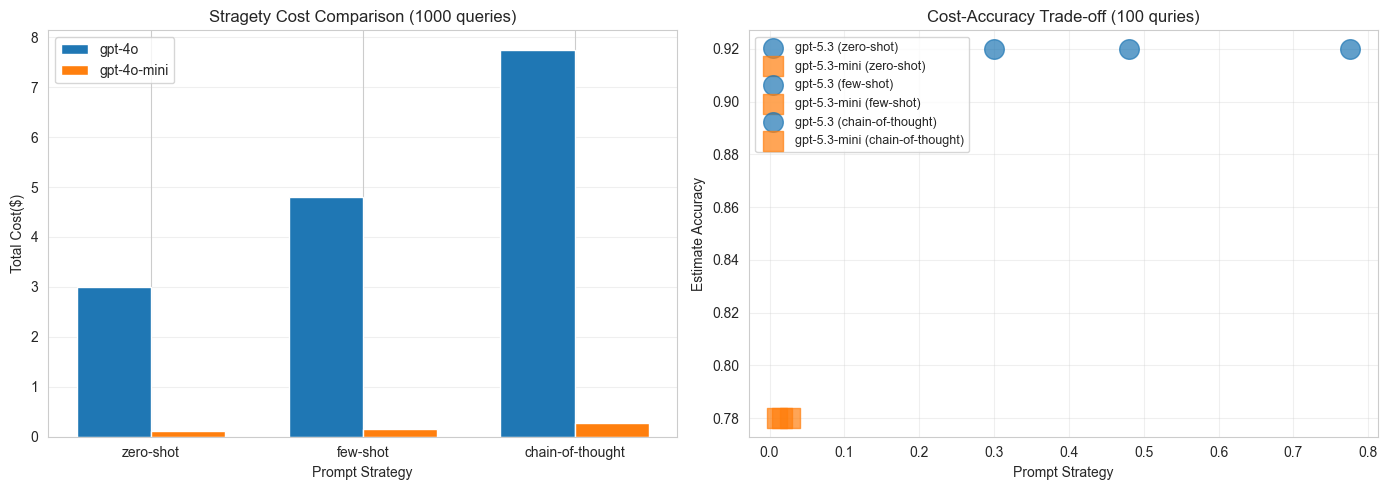

비용-성능 트레이드오프 차트 생성 완료!


In [14]:
# 비용-성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 전략별 비용 비교
strategies = [s.value for s in PromptStrategy]
costs_4o = []
costs_mini = []

for strategy in PromptStrategy:
    results = simulate_batch_processing(1000, strategy)
    costs_4o.append(results['gpt-5.3']['total_cost'])
    costs_mini.append(results['gpt-5.3-mini']['total_cost'])

x = np.arange(len(strategies))
width = 0.35

axes[0].bar(x - width/2, costs_4o, width, label='gpt-4o', color='#1f77b4')
axes[0].bar(x + width/2, costs_mini, width, label='gpt-4o-mini', color='#ff7f0e')
axes[0].set_xlabel('Prompt Strategy')
axes[0].set_ylabel('Total Cost($)')
axes[0].set_title('Stragety Cost Comparison (1000 queries)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 정확도 vs 비용 (scatterplot)
for strategy in PromptStrategy:
    results = simulate_batch_processing(100, strategy)
    
    for model_name, metrics in results.items():
        marker = 'o' if model_name == 'gpt-5.3' else 's'
        color = '#1f77b4' if model_name == 'gpt-5.3' else '#ff7f0e'
        axes[1].scatter(
            metrics['total_cost'],
            metrics['expected_accuracy'],
            s=200,
            marker=marker,
            color=color,
            alpha=0.7,
            label=f"{model_name} ({strategy.value})"
        )

axes[1].set_xlabel('Prompt Strategy')
axes[1].set_ylabel('Estimate Accuracy')
axes[1].set_title('Cost-Accuracy Trade-off (100 quries)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('cost_performance_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()

print("비용-성능 트레이드오프 차트 생성 완료!")

## 7. 프롬프트 템플릿 설계 가이드

인과추론에 최적화된 프롬프트 템플릿의 핵심 원칙:

In [15]:
# 최종 최적화된 프롬프트 템플릿
class CausalInferencePromptTemplate:
    """인과추론 최적화 프롬프트 템플릿"""
    
    @staticmethod
    def system_message() -> str:
        """최적화된 시스템 메시지"""
        return """당신은 인과추론 분야의 경험 있는 데이터 과학자입니다.

당신의 역할:
- 데이터 설명으로부터 인과관계 구조를 파악
- 변수들 간의 인과경로를 식별
- 편향 위험을 평가
- 신뢰도 수준을 명시

당신의 원칙:
1. 명시적 정보와 암시적 맥락 모두 고려
2. 도메인 지식 활용
3. 불확실성은 신뢰도로 표현
4. 모든 주요 결정에 근거 제시
5. 대안적 해석도 고려"""
    
    @staticmethod
    def variable_identification_prompt(
        outcome_query: str,
        treatment_query: str,
        dataset_description: str
    ) -> str:
        """변수 식별 프롬프트"""
        return f"""다음 인과추론 작업을 수행하세요:

작업 정보:
- 인과 질문: "{outcome_query}"
- 처치 변수: "{treatment_query}"

데이터셋 설명:
{dataset_description}

분석 요청:
1. 결과 변수(outcome)를 식별하고 근거를 제시하세요
2. 처치 변수(treatment)를 식별하고 근거를 제시하세요  
3. 교란 변수(confounders)를 식별하고 인과경로를 설명하세요
4. 도구 변수(instruments) 가능성을 평가하세요
5. 각 식별에 대한 신뢰도(0-1)를 제시하세요

출력 형식 (JSON):
{{
  "outcome": {{
    "variable": "변수명",
    "type": "연속|범주",
    "evidence": "식별 근거",
    "confidence": 0.0
  }},
  "treatment": {{
    "variable": "변수명",
    "type": "이진|다중수준",
    "evidence": "식별 근거",
    "confidence": 0.0
  }},
  "confounders": [
    {{
      "variable": "변수명",
      "causal_paths": ["경로1", "경로2"],
      "confidence": 0.0
    }}
  ]
}}"""
    
    @staticmethod
    def cot_prompt(
        query: str,
        dataset_description: str
    ) -> str:
        """Chain-of-Thought 프롬프트"""
        return f"""다음 인과추론 질문에 단계별로 답변하세요:

질문: {query}

데이터셋: {dataset_description}

분석 단계:

단계 1: 질문 이해
- 관심 있는 인과 효과는 무엇인가?
- 이것은 총효과(ATE)인가, 조건부 효과(CATE)인가?

단계 2: 변수 나열
- 데이터셋의 모든 변수를 나열하세요
- 각 변수의 타입과 범위를 설명하세요

단계 3: 인과 그래프 구성
- 각 변수 쌍의 인과관계를 평가하세요
- 교란, 매개, 충돌의 가능성을 고려하세요

단계 4: 식별 전략 선택
- 무작위화된가? (RCT이면 인과추론이 가능)
- 교란을 조정할 수 있는가? (역확률 가중치, 성향점수)
- 도구 변수가 있는가?

단계 5: 편향 위험 평가
- 측정되지 않은 교란의 위험도는?
- 선택 편향의 위험도는?
- 결과:
"""

print("최적화된 프롬프트 템플릿 정의 완료!")
print(f"\n제공되는 템플릿:")
print("1. system_message() - 역할 및 원칙 정의")
print("2. variable_identification_prompt() - 변수 식별")
print("3. cot_prompt() - Chain-of-Thought 분석")

최적화된 프롬프트 템플릿 정의 완료!

제공되는 템플릿:
1. system_message() - 역할 및 원칙 정의
2. variable_identification_prompt() - 변수 식별
3. cot_prompt() - Chain-of-Thought 분석


In [16]:
# 템플릿 예시 출력
template = CausalInferencePromptTemplate()

query = "약물 X가 혈압 감소에 미치는 영향?"
dataset = """환자ID, 나이, 성별, 약물복용여부, 초기혈압, 최종혈압, 
운동빈도, 식습관점수, 기저질환여부"""

print("시스템 메시지:")
print("=" * 70)
print(template.system_message())
print("\n" + "=" * 70)
print("\n변수 식별 프롬프트:")
print(template.variable_identification_prompt(query, "약물복용여부", dataset)[:300] + "...")
print("\n" + "=" * 70)
print("\nChain-of-Thought 프롬프트:")
print(template.cot_prompt(query, dataset)[:300] + "...")

시스템 메시지:
당신은 인과추론 분야의 경험 있는 데이터 과학자입니다.

당신의 역할:
- 데이터 설명으로부터 인과관계 구조를 파악
- 변수들 간의 인과경로를 식별
- 편향 위험을 평가
- 신뢰도 수준을 명시

당신의 원칙:
1. 명시적 정보와 암시적 맥락 모두 고려
2. 도메인 지식 활용
3. 불확실성은 신뢰도로 표현
4. 모든 주요 결정에 근거 제시
5. 대안적 해석도 고려


변수 식별 프롬프트:
다음 인과추론 작업을 수행하세요:

작업 정보:
- 인과 질문: "약물 X가 혈압 감소에 미치는 영향?"
- 처치 변수: "약물복용여부"

데이터셋 설명:
환자ID, 나이, 성별, 약물복용여부, 초기혈압, 최종혈압, 
운동빈도, 식습관점수, 기저질환여부

분석 요청:
1. 결과 변수(outcome)를 식별하고 근거를 제시하세요
2. 처치 변수(treatment)를 식별하고 근거를 제시하세요  
3. 교란 변수(confounders)를 식별하고 인과경로를 설명하세요
4. 도구 변수(instruments) 가능성을 평가하세요
5. 각 ...


Chain-of-Thought 프롬프트:
다음 인과추론 질문에 단계별로 답변하세요:

질문: 약물 X가 혈압 감소에 미치는 영향?

데이터셋: 환자ID, 나이, 성별, 약물복용여부, 초기혈압, 최종혈압, 
운동빈도, 식습관점수, 기저질환여부

분석 단계:

단계 1: 질문 이해
- 관심 있는 인과 효과는 무엇인가?
- 이것은 총효과(ATE)인가, 조건부 효과(CATE)인가?

단계 2: 변수 나열
- 데이터셋의 모든 변수를 나열하세요
- 각 변수의 타입과 범위를 설명하세요

단계 3: 인과 그래프 구성
- 각 변수 쌍의 인과관계를 평가하세요
- 교란, 매개, 충돌의 가능성...


In [17]:
# 프롬프트 엔지니어링 체크리스트
CHECKLIST = {
    "명확성": [
        "모호한 표현 제거",
        "구체적인 예시 포함",
        "명확한 형식 지정"
    ],
    "맥락": [
        "변수 정의",
        "도메인 정보",
        "데이터셋 설명"
    ],
    "구조": [
        "단계별 지시",
        "출력 형식 정의",
        "제약 조건 명시"
    ],
    "역할": [
        "전문가 역할 정의",
        "원칙 설명",
        "책임 명확화"
    ],
    "피드백": [
        "신뢰도 요구",
        "근거 요구",
        "대안 제시 요청"
    ]
}

print("프롬프트 엔지니어링 체크리스트:")
print("=" * 70)
for category, items in CHECKLIST.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  □ {item}")

print("\n" + "=" * 70)
print("\n프롬프트 작성 팁:")
print("1. 간단한 프롬프트부터 시작하세요")
print("2. 반복해서 개선하세요")
print("3. 다양한 입력으로 테스트하세요")
print("4. 결과를 분석하고 피드백을 반영하세요")
print("5. 버전 관리를 하세요")

프롬프트 엔지니어링 체크리스트:

명확성:
  □ 모호한 표현 제거
  □ 구체적인 예시 포함
  □ 명확한 형식 지정

맥락:
  □ 변수 정의
  □ 도메인 정보
  □ 데이터셋 설명

구조:
  □ 단계별 지시
  □ 출력 형식 정의
  □ 제약 조건 명시

역할:
  □ 전문가 역할 정의
  □ 원칙 설명
  □ 책임 명확화

피드백:
  □ 신뢰도 요구
  □ 근거 요구
  □ 대안 제시 요청


프롬프트 작성 팁:
1. 간단한 프롬프트부터 시작하세요
2. 반복해서 개선하세요
3. 다양한 입력으로 테스트하세요
4. 결과를 분석하고 피드백을 반영하세요
5. 버전 관리를 하세요
